# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [2]:
!pip install icrawler
!pip install pyimagedl

import torch

# Desativar TODAS as otimizações do PyTorch 2.x
try:
    torch._dynamo.disable()
except:
    pass

torch.compile = lambda *args, **kwargs: args[0]



In [3]:
import os
import shutil
import random
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [4]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = GoogleImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [5]:
# search_terms = {
#     "bob": "spongebob", # nome da classe: termo que será usado na busca
# }


# for label, term in search_terms.items():
#     download_images(term, f"data/spongebob/{label}", n_total=100)
#!!!!!!Tá dando erro quando roda, procurei uma alternativa...!!!!!

In [6]:
from imagedl import imagedl
import os
import shutil

def download_images_generic(keyword, label, output_dir="data", target_total=100):
    final_folder = os.path.join(output_dir, label)
    os.makedirs(final_folder, exist_ok=True)

    count_existing = len([
        f for f in os.listdir(final_folder)
        if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))
    ])

    if count_existing >= target_total:
        print(f"✅ [{label}] Já possui {count_existing} imagens. Pulando...")
        return

    needed = target_total - count_existing
    print(f"⬇️ [{label}] Possui {count_existing}. Baixando mais {needed} imagens...")

    temp_folder = final_folder + "_tmp"
    if os.path.exists(temp_folder):
        shutil.rmtree(temp_folder)

    try:
        client = imagedl.ImageClient(
            image_source='GoogleImageClient',
            init_image_client_cfg={'work_dir': temp_folder},
            search_limits=needed + 20,
            num_threadings=4,
        )

        image_infos = client.search(keyword, search_limits_overrides=needed + 20)
        client.download(image_infos=image_infos)

        moved = 0
        new_count = count_existing

        for root, dirs, files in os.walk(temp_folder):
            for file in files:
                if moved >= needed:
                    break

                if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    src = os.path.join(root, file)
                    dst = os.path.join(final_folder, f"{label}_{new_count:04d}.jpg")
                    try:
                        shutil.move(src, dst)
                        moved += 1
                        new_count += 1
                    except:
                        pass

        print(f"Concluído! Agora [{label}] tem {new_count} imagens.")

    except Exception as e:
        print(f"Erro ao baixar imagens para {label}: {e}")
    finally:
        if os.path.exists(temp_folder):
            shutil.rmtree(temp_folder)


# -------------------------------------------------------------
# CONFIG PARA O DRIVE
# -------------------------------------------------------------
OUTPUT_DIR = "/content/drive/MyDrive/spongebob_dataset"

classes = {
    "spongebob_squarepants": "spongebob -patrick -sandy -list -gary -scooter -franchise -plankton -recurring",
    "patrick_star": "Patrick Star",
    "squidward_tentacles": "Squidward Tentacles"
}

TARGET_IMAGES = 200

# for label, keyword in classes.items():
#     download_images_generic(keyword, label, output_dir=OUTPUT_DIR, target_total=TARGET_IMAGES)


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [7]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

In [8]:
split_train_val("/content/drive/MyDrive/spongebob_dataset")

spongebob_squarepants: 52 train, 14 val
patrick_star: 108 train, 27 val
squidward_tentacles: 84 train, 21 val


## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [9]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

TRAIN_DIR = "/content/drive/MyDrive/spongebob_dataset_split/train"
VAL_DIR = "/content/drive/MyDrive/spongebob_dataset_split/val"



In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)


print("Classes:", train_dataset.classes)
print("Total treino:", len(train_dataset))
print("Total validação:", len(val_dataset))

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Labels:", labels[:10])



Classes: ['patrick_star', 'spongebob_squarepants', 'squidward_tentacles']
Total treino: 244
Total validação: 62
Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([2, 2, 0, 2, 0, 2, 0, 0, 0, 2])


## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [12]:
import torchvision.models as models
import torch.nn as nn # Adicionar esta linha para importar o módulo nn

NUM_CLASSES = 3


# ----------------------------------------------------------
# A — CNN PRÓPRIA (modelo simples)
# ----------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 112x112
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 56x56
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ----------------------------------------------------------
# B — MobileNetV2 (transfer learning — rápido e eficiente)
# ----------------------------------------------------------
def build_mobilenet(num_classes=3):
    model = models.mobilenet_v2(weights="IMAGENET1K_V1")
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model


# ----------------------------------------------------------
# C — ResNet-50 (alto desempenho)
# ----------------------------------------------------------
def build_resnet50(num_classes=3):
    model = models.resnet50(weights="IMAGENET1K_V2")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# ----------------------------------------------------------
# D — EfficientNet-B0 (ótima acurácia com baixo custo)
# ----------------------------------------------------------
def build_efficientnet(num_classes=3):
    model = models.efficientnet_b0(weights="IMAGENET1K_V1")
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model


# ----------------------------------------------------------
# Função auxiliar para escolher o modelo
# ----------------------------------------------------------
def get_model(name, num_classes=3):
    name = name.lower()
    if name == "cnn":
        return SimpleCNN(num_classes)
    elif name == "mobilenet":
        return build_mobilenet(num_classes)
    elif name == "resnet50":
        return build_resnet50(num_classes)
    elif name == "efficientnet":
        return build_efficientnet(num_classes)
    else:
        raise ValueError("Model name inválido.")

## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [20]:

import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.optim as optim # Adicionar esta linha para importar o otimizador

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# Função de treino + validação
# ---------------------------------------------------------

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        print(f"\nEPOCH {epoch+1}/{epochs}")
        model.train()

        epoch_loss = 0
        correct = 0
        total = 0

        # -------------------- TREINO --------------------
        pbar = tqdm(train_loader, desc="Training", leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = epoch_loss / len(train_loader)

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # -------------------- VALIDAÇÃO --------------------
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        # ---------------- Salvar melhor modelo ----------------
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

    # salvar checkpoint final
    torch.save(best_state, "best_model.pth")
    print(f"\n🎉 Melhor modelo salvo com Val Acc = {best_val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs


# ---------------------------------------------------------
# Função para plotar curvas
# ---------------------------------------------------------

def plot_curves(train_losses, val_losses, train_accs, val_accs):

    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.title("Curva de Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # ACURÁCIA
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.title("Curva de Acurácia")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

In [14]:
def train_and_evaluate(model_name, model, train_loader, val_loader, epochs=8, lr=1e-4):

    print(f"\n==============================")
    print(f" Treinando modelo: {model_name}")
    print(f"==============================")

    train_losses, val_losses, train_accs, val_accs = train_model(
        model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=lr
    )

    best_val_acc = max(val_accs)

    return {
        "name": model_name,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "best_val_acc": best_val_acc
    }


In [15]:
models_to_test = {
    "SimpleCNN": get_model("cnn"),
    "MobileNetV2": get_model("mobilenet"),
    "ResNet50": get_model("resnet50"),
    "EfficientNetB0": get_model("efficientnet")
}


In [21]:

results = []


for name, model in models_to_test.items():
    model = model.to(device)
    r = train_and_evaluate(name, model, train_loader, val_loader)
    results.append(r)



 Treinando modelo: SimpleCNN

EPOCH 1/8


Train Loss: 1.0154 | Train Acc: 0.4877
Val Loss:   0.8752 | Val Acc:   0.6774

EPOCH 2/8


Train Loss: 0.7821 | Train Acc: 0.7500
Val Loss:   0.7047 | Val Acc:   0.7581

EPOCH 3/8


Train Loss: 0.5813 | Train Acc: 0.7705
Val Loss:   0.6222 | Val Acc:   0.7903

EPOCH 4/8


Train Loss: 0.4429 | Train Acc: 0.8648
Val Loss:   0.5129 | Val Acc:   0.8387

EPOCH 5/8


...

Train Loss: 0.3539 | Train Acc: 0.9795
Val Loss:   0.2702 | Val Acc:   0.9677

EPOCH 5/8


Train Loss: 0.2532 | Train Acc: 0.9795
Val Loss:   0.1815 | Val Acc:   0.9677

EPOCH 6/8


Train Loss: 0.1602 | Train Acc: 0.9877
Val Loss:   0.1333 | Val Acc:   0.9677

EPOCH 7/8


Train Loss: 0.0977 | Train Acc: 0.9918
Val Loss:   0.1126 | Val Acc:   0.9677

EPOCH 8/8


Train Loss: 0.0883 | Train Acc: 1.0000
Val Loss:   0.1013 | Val Acc:   0.9677

🎉 Melhor modelo salvo com Val Acc = 0.9677


In [22]:
print("\n===== RESULTADO FINAL =====\n")
for r in results:
    print(f"{r['name']:20s}  |  Best Val Acc: {r['best_val_acc']:.4f}")



===== RESULTADO FINAL =====

SimpleCNN             |  Best Val Acc: 0.8548
MobileNetV2           |  Best Val Acc: 0.9839
ResNet50              |  Best Val Acc: 0.9839
EfficientNetB0        |  Best Val Acc: 0.9677


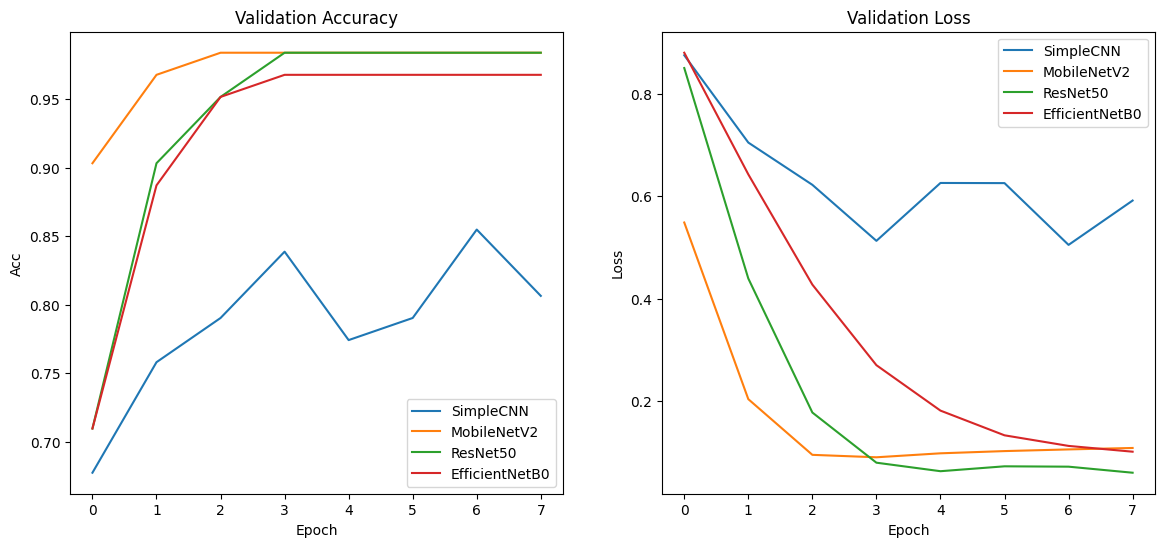

In [23]:
import matplotlib.pyplot as plt

def plot_comparison(results):
    plt.figure(figsize=(14,6))

    # ACCURACY
    plt.subplot(1,2,1)
    for r in results:
        plt.plot(r["val_accs"], label=r["name"])
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Acc")
    plt.legend()

    # LOSS
    plt.subplot(1,2,2)
    for r in results:
        plt.plot(r["val_losses"], label=r["name"])
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_comparison(results)


## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

In [ ]:
# Seu código aqui